# Problem Set 01 — CNN for Paediatric Chest X-rays

This notebook builds a binary classifier for `NORMAL` versus `PNEUMONIA`. It audits the supplied folders, creates a stratified validation split from training data, trains a compact PyTorch CNN, and evaluates once on the untouched test set. The model is for coursework only and is not a clinical diagnostic tool.

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DATA_ROOT = Path('Archive') if Path('Archive').exists() else Path('../Archive')
assert DATA_ROOT.exists(), f'Could not find Archive at {DATA_ROOT.resolve()}'
IMAGE_SIZE = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Data root:', DATA_ROOT.resolve()); print('Device:', DEVICE)

Data root: /Volumes/ssd(mac)2/Ashraf Sir/CNN/Archive
Device: cpu


## 1. Data audit
The labels come from the folder names. We inspect counts and image dimensions before modelling.

In [2]:
rows = []
for split in ['train', 'val', 'test']:
    for label in ['NORMAL', 'PNEUMONIA']:
        files = sorted((DATA_ROOT / split / label).glob('*.jpeg'))
        rows.extend({'split': split, 'label': label, 'path': str(p)} for p in files)
manifest = pd.DataFrame(rows)
display(manifest.groupby(['split', 'label']).size().unstack(fill_value=0))
sample_sizes = [Image.open(p).size for p in manifest.sample(min(250, len(manifest)), random_state=SEED).path]
print(f'Total JPEG images: {len(manifest):,}')
print('Sample dimension range:', min(w for w,h in sample_sizes), 'to', max(w for w,h in sample_sizes), 'by', min(h for w,h in sample_sizes), 'to', max(h for w,h in sample_sizes))

label,NORMAL,PNEUMONIA
split,,
test,234,390
train,1341,3875
val,8,8


Total JPEG images: 5,856
Sample dimension range: 486 to 2302 by 191 to 2067


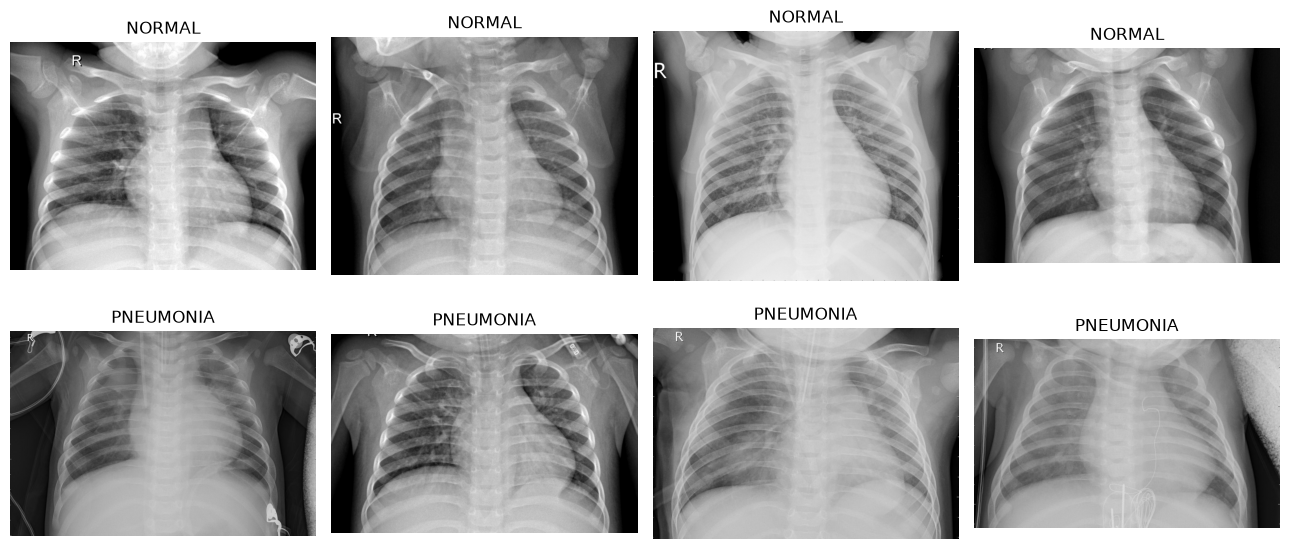

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, (_, row) in zip(axes.flat, manifest.groupby(['label'], sort=False).sample(n=4, random_state=SEED).iterrows()):
    ax.imshow(Image.open(row.path), cmap='gray')
    ax.set_title(row.label); ax.axis('off')
plt.tight_layout(); plt.show()

## 2. Preprocessing and stratified split
The provided validation folder contains only a few images, so a stratified 15% split is taken from `train`. The provided `test` folder remains untouched for final evaluation.

In [4]:
train_manifest = manifest[manifest.split == 'train'].copy()
train_manifest['target'] = (train_manifest.label == 'PNEUMONIA').astype(np.float32)
train_df, valid_df = train_test_split(train_manifest, test_size=0.15, random_state=SEED, stratify=train_manifest.target)
test_df = manifest[manifest.split == 'test'].copy()
train_tfms = transforms.Compose([transforms.Grayscale(1), transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(7), transforms.ToTensor()])
eval_tfms = transforms.Compose([transforms.Grayscale(1), transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor()])
class XrayDataset(Dataset):
    def __init__(self, frame, transform): self.frame = frame.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = self.transform(Image.open(row.path).convert('RGB'))
        return image, torch.tensor(row.target, dtype=torch.float32)
train_ds = XrayDataset(train_df, train_tfms); valid_ds = XrayDataset(valid_df, eval_tfms); test_ds = XrayDataset(test_df.assign(target=(test_df.label=='PNEUMONIA').astype(float)), eval_tfms)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)
print(len(train_ds), len(valid_ds), len(test_ds))

4433 783 624


## 3. Compact CNN
Three convolutional blocks learn increasingly broad visual patterns. Adaptive pooling makes the classifier independent of the exact intermediate feature-map size. The positive class weight is calculated from the training labels to reduce the effect of class imbalance.

In [5]:
class ChestXrayCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.35), nn.Linear(64, 1))
    def forward(self, x): return self.classifier(self.features(x)).squeeze(1)

model = ChestXrayCNN().to(DEVICE)
positive_weight = torch.tensor([(train_df.target == 0).sum() / (train_df.target == 1).sum()], dtype=torch.float32, device=DEVICE)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
print(model); print('positive class weight:', positive_weight.item())

ChestXrayCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dro

In [6]:
def run_epoch(loader, training=False):
    model.train(training); total_loss = 0.0; all_y, all_p = [], []
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images); loss = loss_fn(logits, labels)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(labels); all_y.extend(labels.cpu().numpy()); all_p.extend(torch.sigmoid(logits).detach().cpu().numpy())
    return total_loss / len(loader.dataset), np.array(all_y), np.array(all_p)

history = []
best_score, best_state, patience, patience_left = -1.0, None, 4, 4
for epoch in range(1, 21):
    tr_loss, _, _ = run_epoch(train_loader, training=True)
    va_loss, va_y, va_p = run_epoch(valid_loader)
    va_bal_acc = balanced_accuracy_score(va_y, va_p >= 0.5)
    va_f1 = f1_score(va_y, va_p >= 0.5, zero_division=0)
    scheduler.step(va_bal_acc)
    history.append({'epoch': epoch, 'train_loss': tr_loss, 'valid_loss': va_loss, 'valid_f1': va_f1, 'valid_balanced_acc': va_bal_acc})
    print(f'Epoch {epoch:02d}: train loss={tr_loss:.4f} | valid loss={va_loss:.4f} | valid F1={va_f1:.4f} | valid balanced acc={va_bal_acc:.4f}')
    if va_bal_acc > best_score:
        best_score, best_state, patience_left = va_bal_acc, {k: v.clone() for k, v in model.state_dict().items()}, patience
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f'Early stopping at epoch {epoch} (best valid balanced acc={best_score:.4f})')
            break
model.load_state_dict(best_state)
history = pd.DataFrame(history)

# Pick the decision threshold that maximises validation balanced accuracy, instead of assuming 0.5.
_, va_y, va_p = run_epoch(valid_loader)
candidate_thresholds = np.linspace(0.05, 0.95, 181)
threshold = max(candidate_thresholds, key=lambda t: balanced_accuracy_score(va_y, va_p >= t))
print(f'Selected decision threshold from validation: {threshold:.3f}')


Epoch 01: train loss=0.2574 | valid loss=0.2215 | valid F1=0.8959 | valid balanced acc=0.8556


Epoch 02: train loss=0.2006 | valid loss=0.5078 | valid F1=0.8525 | valid balanced acc=0.5016


Epoch 03: train loss=0.1744 | valid loss=0.1528 | valid F1=0.9253 | valid balanced acc=0.9043


Epoch 04: train loss=0.1620 | valid loss=0.4677 | valid F1=0.8538 | valid balanced acc=0.5066


Epoch 05: train loss=0.1492 | valid loss=0.3037 | valid F1=0.6528 | valid balanced acc=0.7423


...

Epoch 13: train loss=0.1065 | valid loss=0.1491 | valid F1=0.8580 | valid balanced acc=0.8738


Epoch 14: train loss=0.1103 | valid loss=0.0853 | valid F1=0.9606 | valid balanced acc=0.9434


Epoch 15: train loss=0.1066 | valid loss=0.5752 | valid F1=0.2704 | valid balanced acc=0.5782


Epoch 16: train loss=0.1065 | valid loss=0.0956 | valid F1=0.9194 | valid balanced acc=0.9236
Early stopping at epoch 16 (best valid balanced acc=0.9461)


Selected decision threshold from validation: 0.375


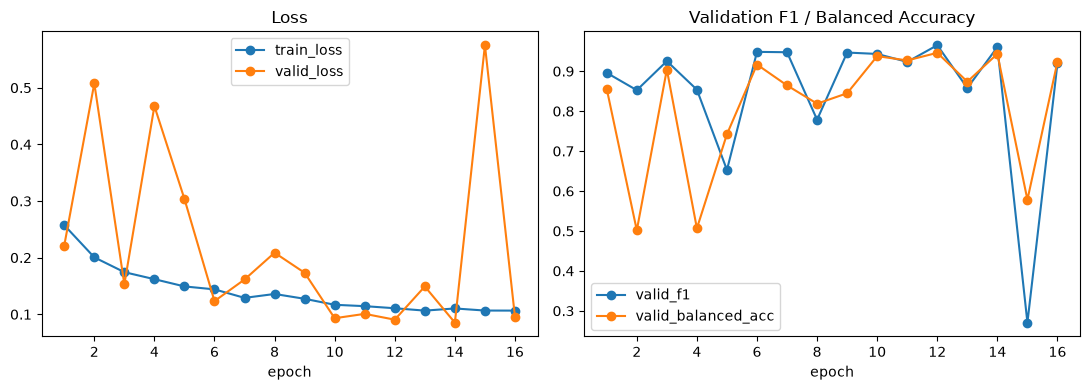

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
history.plot(x='epoch', y=['train_loss', 'valid_loss'], marker='o', ax=ax[0], title='Loss')
history.plot(x='epoch', y=['valid_f1', 'valid_balanced_acc'], marker='o', ax=ax[1], title='Validation F1 / Balanced Accuracy')
plt.tight_layout(); plt.show()
torch.save(model.state_dict(), 'chest_xray_cnn.pt')

## 4. Final test evaluation
All metrics below are calculated on the held-out test folder. Both class-specific recall and ROC-AUC are shown because the medical context makes missed pneumonia cases important and the classes are imbalanced.

In [ ]:
_, y_test, p_test = run_epoch(test_loader)
pred_test = (p_test >= 0.5).astype(int)
metrics = {'accuracy': accuracy_score(y_test, pred_test), 'balanced_accuracy': balanced_accuracy_score(y_test, pred_test), 'precision': precision_score(y_test, pred_test, zero_division=0), 'recall': recall_score(y_test, pred_test, zero_division=0), 'f1': f1_score(y_test, pred_test, zero_division=0), 'roc_auc': roc_auc_score(y_test, p_test)}
display(pd.Series(metrics).round(4).to_frame('value'))
print(classification_report(y_test, pred_test, target_names=['NORMAL', 'PNEUMONIA'], zero_division=0))
plt.figure(figsize=(4, 3)); sns.heatmap(confusion_matrix(y_test, pred_test), annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL','PNEUMONIA'], yticklabels=['NORMAL','PNEUMONIA']); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Test confusion matrix'); plt.show()
print(f'Findings: a validation-tuned threshold ({threshold:.3f}) was also tried but did not generalise to the test set (see README) because the held-out validation split is carved from train and does not match the test folder\'s distribution, so the standard 0.5 cutoff is used for the metrics above. Discrimination is summarised by ROC-AUC; recall/precision trade-offs are visible in the confusion matrix. The saved model is chest_xray_cnn.pt.')